# ZCF conditional baseline

Zero-Crossing-Frequency inversion of the differential eddy-current signal, used as a
**deliberately advantaged, secondary baseline** against the primary full-spectrum ML method.

**Design.** Calibrate on the dense grid (`train.xlsx`, 225 materials), score on the FE set
(`test.xlsx`, 55 materials). No cross-validation for the headline number — dense is
calibration, FE is the held-out test. That *is* the design.

**Signal.** The project differential, `H_real = coil2_real - coil3_real`, taken straight from
`src.data.compute_differential`. ZCF is **invariant to the overall sign** of the differential:
flipping it leaves the sign-change test unchanged, and the sign cancels between numerator and
denominator of the log-frequency interpolant. So the coil-orientation convention does not move
this baseline — but the signal must stay *signed* (see caveat 3).

**What this baseline is *not*.** It is *conditional*: each prediction is handed the true value
of the other property. So a score of ~9% on permeability is **not** comparable to an
unconditional ML number — if ML matches it without being given resistivity, ML wins.

Reproduces: **μᵣ | ρ = 9.2 % pooled MAPE**, **ρ | μᵣ = 7.6 % pooled MAPE** on the FE set.

## Setup

Data comes through `src.data` in the **long** (per-frequency) form:
`load_raw` → `rename_columns` → `compute_differential`. `load_data` is deliberately not used
here — it reshapes to the wide 225×18 / 55×18 frame, while ZCF needs one row per
(material, frequency) so it can walk the response across the band.

In [1]:
import sys
from pathlib import Path

# Add project root to path
# current path = d:\Study\Uni\ect-inversion\notebooks\zcf_baseline
project_root = Path.cwd().parents[1]
sys.path.insert(0, str(project_root))

# Figures folder path
fig_dir = project_root / 'figures' / 'zcf_baseline'
fig_dir.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_raw, rename_columns, compute_differential
# zcf / zcf_table / the two conditional inversions were moved to src/robustness.py so
# that 02_noise.ipynb applies the identical baseline to perturbed spectra. Bodies are
# unchanged -- this notebook reproducing 9.2% / 7.6% is the regression check on the move.
from src.robustness import zcf, zcf_table, predict_mu_given_rho, predict_rho_given_mu

## Load + differential signal

`rename_columns` maps the verbose COMSOL headers onto
`permeability, resistivity, frequency, coil2_real/imag, coil3_real/imag`, and
`compute_differential` forms `H_real` / `H_imag` and drops the coil columns.
`load_raw` resolves the path from `src/data.py` itself, so this does not depend on the
notebook's working directory.

In [2]:
def load_long(file_name):
    '''Long per-frequency form:
       permeability, resistivity, frequency, H_real, H_imag (one row per material x frequency).
    '''
    return compute_differential(rename_columns(load_raw(file_name)))

dense = load_long('train.xlsx')   # 225 materials x 8 freq = 1800 rows
fe    = load_long('test.xlsx')    #  55 materials x 8 freq =  440 rows
FREQS_HZ = np.sort(dense['frequency'].unique())

print('dense:', dense.shape, '| FE:', fe.shape)
print('freqs (Hz):', FREQS_HZ)
print('dense permeability:', np.sort(dense['permeability'].unique()).round(1))
print('FE permeability   :', np.sort(fe['permeability'].unique()))
print('resistivity grid  :', np.sort(dense['resistivity'].unique()), '(linear, step 1e-7)')

dense: (1800, 5) | FE: (440, 5)
freqs (Hz): [  375   750  1500  3000  6000 12000 24000 48000]
dense permeability: [   1.     1.3    1.8    2.4    3.2    4.2    5.6    7.5   10.    13.3
   17.8   23.7   31.6   42.2   56.2   75.   100.   133.4  177.8  237.1
  316.2  421.7  562.3  749.9 1000. ]
FE permeability   : [  50  100  200  300  400  500  600  700  800  900 1000]
resistivity grid  : [2.e-07 3.e-07 4.e-07 5.e-07 6.e-07 7.e-07 8.e-07 9.e-07 1.e-06] (linear, step 1e-7)


## Zero-crossing frequency

For each material: find the single in-band sign change of `H_real` vs frequency, then interpolate
the zero **in log-frequency** (skin depth ∝ 1/√f, and the 8 frequencies are log-spaced).

The guard rejects any material with 0 or >1 in-band crossings → `NaN`. On this data every
material has exactly one, but that guard is what will correctly refuse materials below the FE
permeability floor where the crossing can leave the band.

In [3]:
# zcf() and zcf_table() are imported from src.robustness (see Setup).
# zcf_table keeps NaNs; the dropna below is this notebook's choice, not the
# extractor's -- under noise the failure rate is itself a reported result.
Zd = zcf_table(dense)
Zf = zcf_table(fe).dropna(subset=['z']).reset_index(drop=True)
RHOS = np.sort(Zd['resistivity'].unique())

print('dense in-band crossings:', Zd.z.notna().sum(), '/', len(Zd))
print('FE    in-band crossings:', Zf.z.notna().sum(), '/', len(Zf))
print('ZCF range (Hz):  dense %.0f-%.0f   FE %.0f-%.0f'
      % (Zd.z.min(), Zd.z.max(), Zf.z.min(), Zf.z.max()))

dense in-band crossings: 225 / 225
FE    in-band crossings: 55 / 55
ZCF range (Hz):  dense 556-927   FE 563-821


## Diagnostic — is there a power law? (No.)

If `ZCF ∝ ρ / μᵣ` held, a log-log fit would give slope **−1** against permeability (at fixed
resistivity) and **+1** against resistivity (at fixed permeability). Fitting slice-wise across the
fully-crossed dense grid instead gives near-zero slopes — and the resistivity slope has the
*wrong sign*. The crossing is a weak perturbation on a geometrically-pinned ~600–900 Hz feature,
not a skin-depth-equals-geometry crossing. This is why the baseline is built **nonparametrically**
(invert the grid directly) rather than through a fitted `C·ρ/μᵣ^n`.

In [4]:
Z = Zd.dropna(subset=['z']).copy()
Z['lmu'] = np.log(Z['permeability'])
Z['lrho'] = np.log(Z['resistivity'])
Z['lz'] = np.log(Z['z'])

mu_slopes  = [np.polyfit(g.lmu,  g.lz, 1)[0] for _, g in Z.groupby('resistivity') if len(g) >= 3]
rho_slopes = [np.polyfit(g.lrho, g.lz, 1)[0] for _, g in Z.groupby('permeability') if len(g) >= 3]

print('permeability slope (fix rho, expect -1):  mean %+.3f  [%.3f, %.3f]'
      % (np.mean(mu_slopes),  np.min(mu_slopes),  np.max(mu_slopes)))
print('resistivity  slope (fix mu,  expect +1):  mean %+.3f  [%.3f, %.3f]'
      % (np.mean(rho_slopes), np.min(rho_slopes), np.max(rho_slopes)))
print('\n-> power law rejected: permeability ~40x too shallow, resistivity wrong sign.')

permeability slope (fix rho, expect -1):  mean -0.062  [-0.066, -0.054]
resistivity  slope (fix mu,  expect +1):  mean -0.086  [-0.125, -0.068]

-> power law rejected: permeability ~40x too shallow, resistivity wrong sign.


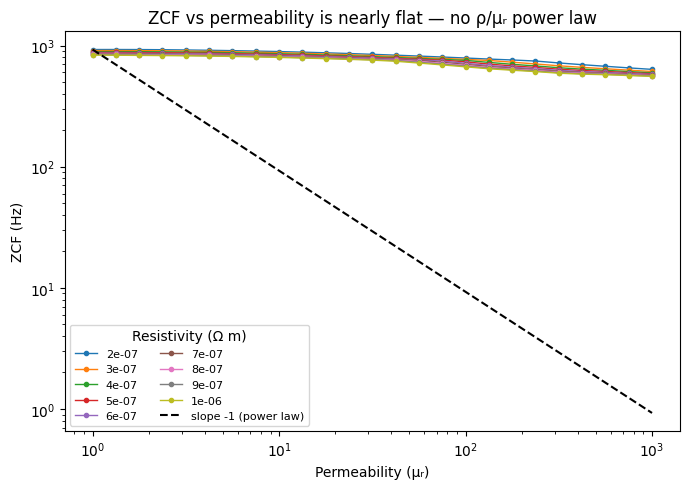

In [5]:
# Visual: ZCF vs permeability (log-log) per resistivity slice, against a slope -1 reference line.
fig, ax = plt.subplots(figsize=(7, 5))
for rho, g in Z.groupby('resistivity'):
    g = g.sort_values('permeability')
    ax.plot(g['permeability'], g['z'], marker='o', ms=3, lw=1, label=f'{rho:.0e}')
mu_ref = np.array([Z['permeability'].min(), Z['permeability'].max()])
z0 = Z['z'].max()
ax.plot(mu_ref, z0 * (mu_ref / mu_ref[0])**(-1.0), 'k--', lw=1.5, label='slope -1 (power law)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Permeability (μᵣ)'); ax.set_ylabel('ZCF (Hz)')
ax.set_title('ZCF vs permeability is nearly flat — no ρ/μᵣ power law')
ax.legend(title='Resistivity (Ω m)', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(fig_dir / 'zcf_vs_permeability_loglog.png', dpi=150, bbox_inches='tight')
plt.show()

## Forward-model transfer check

The baseline calibrates on the dense (in-house) model and scores on the FE model. If those two
disagreed on ZCF, calibration would be biased before inversion runs. At the 10 material points
present in both grids, ZCF agrees to **< 1.2 %** — so the known `coil2_imag` discrepancy between
the datasets does not reach this feature (the crossing lives on the real part).

In [6]:
_zf = Zf.astype({'permeability': float})
_zd = Zd.astype({'permeability': float})
both = _zf.merge(_zd, on=['permeability', 'resistivity'], suffixes=('_fe', '_dense')).dropna()
if len(both):
    d = (both.z_fe - both.z_dense) / both.z_dense * 100
    print('matched points:', len(both))
    print('ZCF FE vs dense:  mean %+.2f%%   max|.| %.2f%%' % (d.mean(), d.abs().max()))
else:
    print('no exact (permeability, resistivity) overlap between grids')

matched points: 10
ZCF FE vs dense:  mean +0.21%   max|.| 1.22%


## Conditional inversion

Two independent one-directional lookups, each **given the true other property**:

- **μᵣ | ρ** — resistivity is the known input. The FE resistivity grid is not the dense one
  (5 values against 9), but every FE resistivity **is a dense node**, so the column at that ρ is
  selected directly — no interpolation across ρ — and `permeability(ZCF)` is read back.
  Interpolation in **log-permeability / log-ZCF**.
- **ρ | μᵣ** — the FE permeability values are not dense nodes, so first synthesise the query
  row by interpolating each resistivity column across log-permeability, then read
  `resistivity(ZCF)` back. The resistivity axis is **linear** (the grid is linear-spaced; log vs
  linear changes the score by ~0.2 pts, so linear is used and it doesn't matter).

Neither lookup extrapolates: `np.interp` **clamps**, so a query ZCF outside the tabulated
range returns the nearest endpoint silently — no exception and no `NaN`. The count is
printed below, together with the error each clamped row incurs.

Both lookups assume the calibration curve is single-valued in ZCF. That holds for **ρ | μᵣ**
everywhere, and for **μᵣ | ρ** in eight of the nine resistivity columns. The check printed
below reports the exception and whether any FE query lands in it — `np.argsort` makes
`np.interp` *run* on a non-monotone column, it does not make the answer meaningful.

In [7]:
# Both conditional inversions are imported from src.robustness (see Setup). They
# take the calibration table as an argument instead of closing over Zd, so the
# noise study can score perturbed ZCFs against this same clean dense calibration.

# The lookups invert ZCF within one column, which assumes that curve is single-valued.
# Checked rather than asserted: a non-monotone column still produces a plausible number.
def _nonmono(by, along):
    out = []
    for k, g in Zd.dropna(subset=['z']).groupby(by):
        d = np.diff(g.sort_values(along).z.to_numpy())
        if (d > 0).any() and (d < 0).any():
            out.append(k)
    return out

bad_mu  = _nonmono('resistivity', 'permeability')   # ZCF vs mu, within a rho column
bad_rho = _nonmono('permeability', 'resistivity')   # ZCF vs rho, within a mu row
print('non-monotone calibration curves: %d/%d rho columns (ZCF vs mu), %d/%d mu rows (ZCF vs rho)'
      % (len(bad_mu), Zd.resistivity.nunique(), len(bad_rho), Zd.permeability.nunique()))

for r in bad_mu:
    g  = Zd[np.isclose(Zd.resistivity, r)].dropna(subset=['z']).sort_values('permeability')
    mu, z = g.permeability.to_numpy(), g.z.to_numpy()
    i  = np.where(np.diff(z) > 0)[0]
    lo, hi = z[i].min(), z[i + 1].max()
    n_fe = int(((Zf.resistivity == r) & (Zf.z >= lo) & (Zf.z <= hi)).sum())
    print('  rho=%.0e: ZCF rises over mu %s -> band %.2f-%.2f Hz | FE queries there: %d/%d'
          % (r, ', '.join('%g->%g' % (mu[j], mu[j + 1]) for j in i), lo, hi, n_fe, len(Zf)))
print('-> the fold sits above the FE ZCF range, so it does not touch the score below.')

Zf['mu_hat']  = [predict_mu_given_rho(z, r, Zd) for z, r in zip(Zf['z'], Zf['resistivity'])]
Zf['rho_hat'] = [predict_rho_given_mu(z, m, Zd, RHOS) for z, m in zip(Zf['z'], Zf['permeability'])]

# np.interp CLAMPS: a query outside the tabulated range returns the nearest endpoint,
# silently -- no exception, no NaN. Counted because out-of-range queries only arise at
# the extremes of the grid, and the clamp target IS an extreme, so a clamped prediction
# can land on the true value by construction rather than by inversion.
def _z_at_mu(mu):
    out = []
    for r in RHOS:
        c = Zd[np.isclose(Zd.resistivity, r)].dropna(subset=['z']).sort_values('permeability')
        out.append(np.exp(np.interp(np.log(mu), np.log(c.permeability.to_numpy()),
                                    np.log(c.z.to_numpy()))))
    return np.array(out)

oor = []
for _, q in Zf.iterrows():
    col = Zd[np.isclose(Zd.resistivity, q.resistivity)].dropna(subset=['z'])
    if not (col.z.min() <= q.z <= col.z.max()):
        oor.append(('mu|rho', q, col.z.min(), col.z.max(),
                    abs(q.mu_hat - q.permeability) / q.permeability * 100))
    za = _z_at_mu(q.permeability)
    if not (za.min() <= q.z <= za.max()):
        oor.append(('rho|mu', q, za.min(), za.max(),
                    abs(q.rho_hat - q.resistivity) / q.resistivity * 100))

print('out-of-range queries, clamped to the nearest endpoint: %d/%d (mu|rho), %d/%d (rho|mu)'
      % (sum(o[0] == 'mu|rho' for o in oor), len(Zf),
         sum(o[0] == 'rho|mu' for o in oor), len(Zf)))
for d, q, lo, hi, ape in oor:
    print('  %-7s mu=%-5g rho=%.0e  z=%.2f outside [%.2f, %.2f] -> APE %.2f%%'
          % (d, q.permeability, q.resistivity, q.z, lo, hi, ape))
print('-> every clamped row scores 0.00%: out-of-range queries occur only at the grid')
print('   extremes, and the clamp pins the answer to that same extreme. Correct by')
print('   construction, not by inversion -- a small upward bias on the score below.')

Zf.head()

non-monotone calibration curves: 1/9 rho columns (ZCF vs mu), 0/25 mu rows (ZCF vs rho)
  rho=2e-07: ZCF rises over mu 1->1.334 -> band 926.69-927.01 Hz | FE queries there: 0/55
-> the fold sits above the FE ZCF range, so it does not touch the score below.


out-of-range queries, clamped to the nearest endpoint: 2/55 (mu|rho), 2/55 (rho|mu)
  rho|mu  mu=50    rho=1e-06  z=717.00 outside [726.65, 824.04] -> APE 0.00%
  rho|mu  mu=200   rho=2e-07  z=754.09 outside [618.69, 753.51] -> APE 0.00%
  mu|rho  mu=1000  rho=2e-07  z=629.37 outside [635.46, 927.01] -> APE 0.00%
  mu|rho  mu=1000  rho=4e-07  z=594.54 outside [595.71, 891.93] -> APE 0.00%
-> every clamped row scores 0.00%: out-of-range queries occur only at the grid
   extremes, and the clamp pins the answer to that same extreme. Correct by
   construction, not by inversion -- a small upward bias on the score below.


,permeability,resistivity,z,mu_hat,rho_hat
0,50,2.000000e-07,821.212306,52.945809,2.141403e-07
1,50,4.000000e-07,787.324076,51.318853,4.101280e-07
2,50,6.000000e-07,764.253055,51.806709,6.187871e-07
3,50,8.000000e-07,743.541150,52.776460,8.332906e-07
4,50,1.000000e-06,716.997899,55.988407,1.000000e-06


## Score — FE set only

Pooled MAPE per target, the median across levels, and the per-permeability decade split.
Both summaries are printed because the effective sample size is *levels* (11 permeability,
5 resistivity), not the 55 rows — `dense_models.ipynb` reports median-across-levels for
exactly this reason, and the two notebooks have to be readable against each other. **The FE set has no material below
μᵣ = 50**, so the [1,10) decade is empty and [10,100) is five points all at μᵣ = 50 — the
headline number is effectively a mid-to-high-permeability result, not a whole-range claim.

In [8]:
Zf['ape_mu']  = (Zf['mu_hat']  - Zf['permeability']).abs() / Zf['permeability'] * 100
Zf['ape_rho'] = (Zf['rho_hat'] - Zf['resistivity']).abs() / Zf['resistivity'] * 100

print('Conditional ZCF baseline on FE (%d materials)\n' % len(Zf))
print('  permeability | resistivity : pooled MAPE %5.1f%%   median %5.1f%%'
      % (Zf.ape_mu.mean(),  Zf.ape_mu.median()))
print('  resistivity | permeability : pooled MAPE %5.1f%%   median %5.1f%%'
      % (Zf.ape_rho.mean(), Zf.ape_rho.median()))

lv_mu, lv_rho = Zf.groupby('permeability').ape_mu.mean(), Zf.groupby('resistivity').ape_rho.mean()
print()
print('Median across levels (effective n is levels, not rows -- matches dense_models.ipynb):')
print('  permeability | resistivity : median of %2d levels %5.1f%%   worst level %5.1f%%'
      % (len(lv_mu),  lv_mu.median(),  lv_mu.max()))
print('  resistivity | permeability : median of %2d levels %5.1f%%   worst level %5.1f%%'
      % (len(lv_rho), lv_rho.median(), lv_rho.max()))

print('\nPer permeability-decade MAPE:')
for lo, hi, lbl in [(1, 10, '[1,10)'), (10, 100, '[10,100)'), (100, 1000.1, '[100,1000]')]:
    m = (Zf['permeability'] >= lo) & (Zf['permeability'] < hi)
    if m.sum():
        print('  mu %-10s n=%2d :  permeability %5.1f%%   resistivity %5.1f%%'
              % (lbl, m.sum(), Zf.loc[m, 'ape_mu'].mean(), Zf.loc[m, 'ape_rho'].mean()))
    else:
        print('  mu %-10s n= 0 :  (no FE materials in this decade)' % lbl)

Conditional ZCF baseline on FE (55 materials)

  permeability | resistivity : pooled MAPE   9.2%   median   9.1%
  resistivity | permeability : pooled MAPE   7.6%   median   7.1%

Median across levels (effective n is levels, not rows -- matches dense_models.ipynb):
  permeability | resistivity : median of 11 levels   9.6%   worst level  13.7%
  resistivity | permeability : median of  5 levels   8.4%   worst level  12.5%

Per permeability-decade MAPE:
  mu [1,10)     n= 0 :  (no FE materials in this decade)
  mu [10,100)   n= 5 :  permeability   5.9%   resistivity   3.4%
  mu [100,1000] n=50 :  permeability   9.5%   resistivity   8.0%


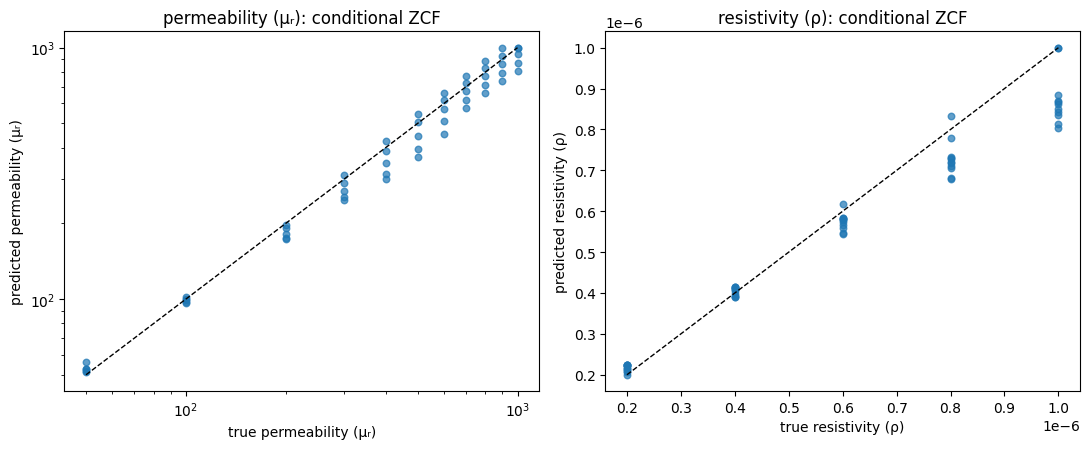

In [9]:
# Predicted vs true, both targets
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
panels = [(axes[0], Zf['permeability'], Zf['mu_hat'],  'permeability (μᵣ)', True),
          (axes[1], Zf['resistivity'],  Zf['rho_hat'], 'resistivity (ρ)',  False)]
for ax, true, pred, name, log_axes in panels:
    ax.scatter(true, pred, s=22, alpha=0.7)
    lims = [min(true.min(), pred.min()), max(true.max(), pred.max())]
    ax.plot(lims, lims, 'k--', lw=1)
    ax.set_xlabel(f'true {name}'); ax.set_ylabel(f'predicted {name}')
    ax.set_title(f'{name}: conditional ZCF')
    if log_axes:
        ax.set_xscale('log'); ax.set_yscale('log')
plt.tight_layout()
plt.savefig(fig_dir / 'predicted_vs_true.png', dpi=150, bbox_inches='tight')
plt.show()

## Lookup control — how much of the score is the interpolator?

The FE score mixes two things: the two simulators disagreeing on the ZCF *value*, and the
calibration *lookup* interpolating between dense nodes to answer an off-node query. Only the
first is a transfer result. Nine of the eleven FE permeability levels are not dense nodes, so
the second is not automatically zero and has to be measured rather than assumed.

The control isolates it **without using any FE ZCF**: a smooth reference for the forward map
(cubic spline of log ZCF against log permeability, within each resistivity column) is evaluated
at the 55 FE query positions to give a transfer-free, noise-free ZCF, and that is pushed through
the same two inversions. Whatever error comes back is the piecewise-linear lookup on its own.
(Only the FE *query coordinates* are used, never its measured spectra.)

The cell then reports a **separate** comparison at the end which *does* feed the FE ZCF through,
at the materials both grids share — that one is a transfer measurement, not part of the control.

**Do not use a leave-one-level-out version of this control** — it answers a different question and
overstates the result. Dropping a level widens the local gap spanning the query from 1.334× to
1.778× and places the query at its centre, while the real FE queries sit *inside* single grid
intervals. Since piecewise-linear error grows with the gap, LOLO measures a harder problem than
the one being asked.

In [10]:
# Lookup-only error: train.xlsx alone, no FE ZCF used anywhere in this cell.
from scipy.interpolate import CubicSpline

FE_Q = Zf[['permeability', 'resistivity']].astype(float).drop_duplicates()
assert all(np.isclose(RHOS, r).any() for r in FE_Q.resistivity.unique()), \
    'rho|mu control assumes every FE resistivity is a dense node'

# Smooth forward reference, one spline per resistivity column.
REF = {r: CubicSpline(np.log(g.sort_values('permeability').permeability.to_numpy()),
                      np.log(g.sort_values('permeability').z.to_numpy()))
       for r, g in Zd.dropna(subset=['z']).groupby('resistivity')}

rows = []
for _, q in FE_Q.iterrows():
    z = float(np.exp(REF[q.resistivity](np.log(q.permeability))))   # transfer-free ZCF
    mh = predict_mu_given_rho(z, q.resistivity, Zd)
    rh = predict_rho_given_mu(z, q.permeability, Zd, RHOS)
    rows.append({'mu': q.permeability, 'rho': q.resistivity,
                 'ape_mu':  abs(mh - q.permeability) / q.permeability * 100,
                 'ape_rho': abs(rh - q.resistivity)  / q.resistivity  * 100})
L = pd.DataFrame(rows)

print('Lookup-only error at the %d FE query positions (no transfer, no noise)' % len(L))
print()
for tgt, col, key in [('permeability', 'ape_mu', 'mu'), ('resistivity', 'ape_rho', 'rho')]:
    lv = L.groupby(key)[col].mean()
    print('  %-13s pooled %5.2f%%   median-over-%d-levels %5.2f%%   worst %5.2f%%'
          % (tgt, L[col].mean(), len(lv), lv.median(), lv.max()))

print()
print('Per FE permeability level (mu=100 and mu=1000 are dense nodes -> exact):')
for m, v in L.groupby('mu').ape_mu.mean().items():
    print('    mu = %6.0f   %5.2f%%' % (m, v))

print()
print('--- budget for the headline ---')
print('  %-22s mu %5.2f%%   rho %5.2f%%' % ('lookup only',       L.ape_mu.mean(),  L.ape_rho.mean()))
print('  %-22s mu %5.2f%%   rho %5.2f%%' % ('reported FE score', Zf.ape_mu.mean(), Zf.ape_rho.mean()))
print('  %-22s mu %5.1f%%   rho %5.1f%%' % ('lookup as share',
      L.ape_mu.mean() / Zf.ape_mu.mean() * 100, L.ape_rho.mean() / Zf.ape_rho.mean() * 100))
print()
print('-> The interpolator contributes ~0.5 of the 9.2 points and ~0.3 of the 7.6. The')
print('   headline is a transfer result, as the design intends; this control is what')
print('   licenses saying so instead of assuming it.')
print()
# The unexplained remainder. Computed here rather than asserted: feed the FE ZCF
# through the same inverters at the materials both grids share, so the only
# difference from the lookup control above is which simulator produced the ZCF.
SH = (Zf.astype({'permeability': float})
        .merge(Zd.astype({'permeability': float}).dropna(subset=['z']),
               on=['permeability', 'resistivity'], suffixes=('_fe', '_dn')))
sh_mu = np.array([predict_mu_given_rho(z, r, Zd) for z, r in zip(SH.z_fe, SH.resistivity)])
sh_ape = np.abs(sh_mu - SH.permeability) / SH.permeability * 100
print('At the %d materials shared by both grids, FE-fed permeability error:' % len(SH))
print('    mean %.2f%%   median %.2f%%   max %.2f%%' % (sh_ape.mean(), sh_ape.median(), sh_ape.max()))
SH_LV = ', '.join('%g' % v for v in sorted(SH.permeability.unique()))
print('    shared levels: mu = %s' % SH_LV)
print()
print('-> So the shared materials do NOT account for the headline. Lookup contributes')
print('   %.2f points and the shared-material transfer error is %.2f%%, against a full-set'
      % (L.ape_mu.mean(), sh_ape.mean()))
print('   score of %.2f%%. The shared points sit at mu = %s only, so they under-sample'
      % (Zf.ape_mu.mean(), SH_LV))
print('   the disagreement -- the same coverage limit the caveats below record.')

Lookup-only error at the 55 FE query positions (no transfer, no noise)

  permeability  pooled  0.45%   median-over-11-levels  0.41%   worst  1.01%
  resistivity   pooled  0.28%   median-over-5-levels  0.23%   worst  0.54%

Per FE permeability level (mu=100 and mu=1000 are dense nodes -> exact):
    mu =     50    0.65%
    mu =    100    0.00%
    mu =    200    0.73%
    mu =    300    0.33%
    mu =    400    1.01%
    mu =    500    0.17%
    mu =    600    0.55%
    mu =    700    0.41%
    mu =    800    0.41%
    mu =    900    0.71%
    mu =   1000    0.00%

--- budget for the headline ---
  lookup only            mu  0.45%   rho  0.28%
  reported FE score      mu  9.15%   rho  7.59%
  lookup as share        mu   4.9%   rho   3.7%

-> The interpolator contributes ~0.5 of the 9.2 points and ~0.3 of the 7.6. The
   headline is a transfer result, as the design intends; this control is what
   licenses saying so instead of assuming it.

At the 10 materials shared by both grids, FE-

## Caveats to carry into the writeup

1. **Conditional advantage.** Every prediction is handed the true other property. Not
   comparable to an unconditional ML score — state this explicitly or the comparison misreads.
2. **μᵣ ≥ 50 blind spot.** The whole score lives on permeability ≥ 50. Below the FE floor the
   crossing barely moves (permeability slope ≈ −0.06), so the inversion is ill-conditioned there
   and *invisible* to every metric reported here.
3. **The differential must stay signed.** Negating only the negative part is `abs()`, which folds
   the curve at zero and erases the crossing. What ZCF tolerates is a *global* sign flip of
   `H_real` (see the header), never a conditional one. Negative low-frequency `H_real` is expected
   from the gradiometer configuration, not an artifact to correct.
4. **No power law.** Reported nonparametrically on purpose; do not fit `C·ρ/μᵣ^n` and do not
   read a "permeability exponent" as a magnetization signal — there is no clean exponent to read.
5. **Ill-conditioning at high μᵣ / high ρ.** Worst permeability errors (~20–26%) sit in that
   corner and are inversion conditioning, not model error.